In [1]:
# 导入科学计算库
import numpy as np
# 导入绘图库
import matplotlib.pyplot as plt
# 导入决策树模块
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
# 导入红酒数据库
from sklearn.datasets import load_wine
# 导入数据划分模块
from sklearn.model_selection import train_test_split
# 导入数据标准化模块
from sklearn.preprocessing import StandardScaler

In [7]:
# 加载红酒数据
wine = load_wine()
print('数据基本信息:', wine.data.shape)
print('特征名称：', wine.feature_names)

# 分离特征与类别标记
x = wine.data
y = wine.target

wine

数据基本信息: (178, 13)
特征名称： ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [4]:
x

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [8]:
# 数据标准化
scaler = StandardScaler()
x_ = scaler.fit_transform(x)

In [9]:
# 将数据划分为训练数据与测试数据
x_train, x_test, y_train, y_test = train_test_split(x_, y, test_size=0.3, random_state=10)

In [10]:
# 构建决策树模型[不同深度]
depth_list = np.arange(2, 10, 1)
Acc_Train = []
Acc_Test = []
for i in depth_list:
    DT = DecisionTreeClassifier(max_depth=i, random_state=10)
    DT.fit(x_train, y_train)
    Acc_Train.append(DT.score(x_train, y_train))
    Acc_Test.append(DT.score(x_test, y_test))

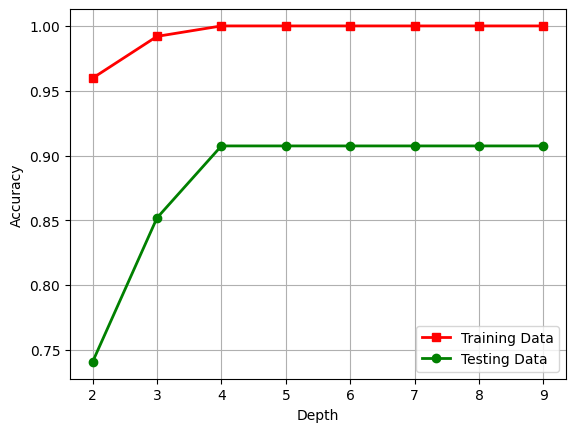

In [11]:
# 显示精度变化
plt.figure(1)
plt.plot(depth_list, Acc_Train, color='r', marker='s', label='Training Data', linewidth=2)
plt.plot(depth_list, Acc_Test, color='g', marker='o', label='Testing Data', linewidth=2)
plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()

上述观察到，在深度为 4 的时候，已经准确率很高了

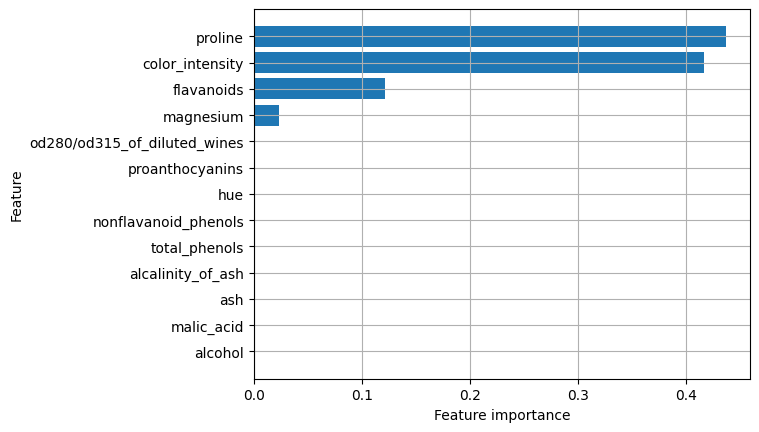

In [12]:
# 显示特征的重要性
DT = DecisionTreeClassifier(max_depth=4, random_state=10)
DT.fit(x_train, y_train)
feature_importance = DT.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
plt.figure(2)
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, np.array(wine.feature_names)[sorted_idx])
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.grid(True)
plt.show()

| 英文原名 | 中文翻译 | 简要说明 |
| :--- | :--- | :--- |
| **alcohol** | **酒精含量** | 葡萄酒中的乙醇浓度。 |
| **malic_acid** | **苹果酸** | 一种有机酸，影响酒的酸度和口感（未发酵的酸）。 |
| **ash** | **灰分** | 燃烧后留下的无机矿物质残留物总量。 |
| **alcalinity_of_ash** | **灰分碱度** | 灰分的碱性程度，反映矿物质的组成。 |
| **magnesium** | **镁** | 一种矿物质元素，来自土壤和葡萄。 |
| **total_phenols** | **总酚含量** | 酚类化合物的总量，影响酒的颜色、口感和陈年潜力。 |
| **flavanoids** | **类黄酮** | 酚类的一种，主要贡献颜色和抗氧化性（来自葡萄皮）。 |
| **nonflavanoid_phenols** | **非类黄酮酚** | 另一类酚化合物（如酚酸），也影响颜色和味道。 |
| **proanthocyanins** | **原花青素** | 一种多酚，主要影响单宁结构和口感涩度。 |
| **color_intensity** | **颜色强度** | 葡萄酒颜色的深浅程度。 |
| **hue** | **色调** | 颜色的具体类型（如偏红、偏紫或偏棕），反映酒的陈年状态。 |
| **od280/od315_of_diluted_wines** | **稀释酒的 OD280/OD315 比值** | 在特定波长下的吸光度比值，用于衡量酚类物质的组成比例。 |
| **proline** | **脯氨酸** | 一种氨基酸，葡萄酒中含量最丰富的氨基酸之一。 |


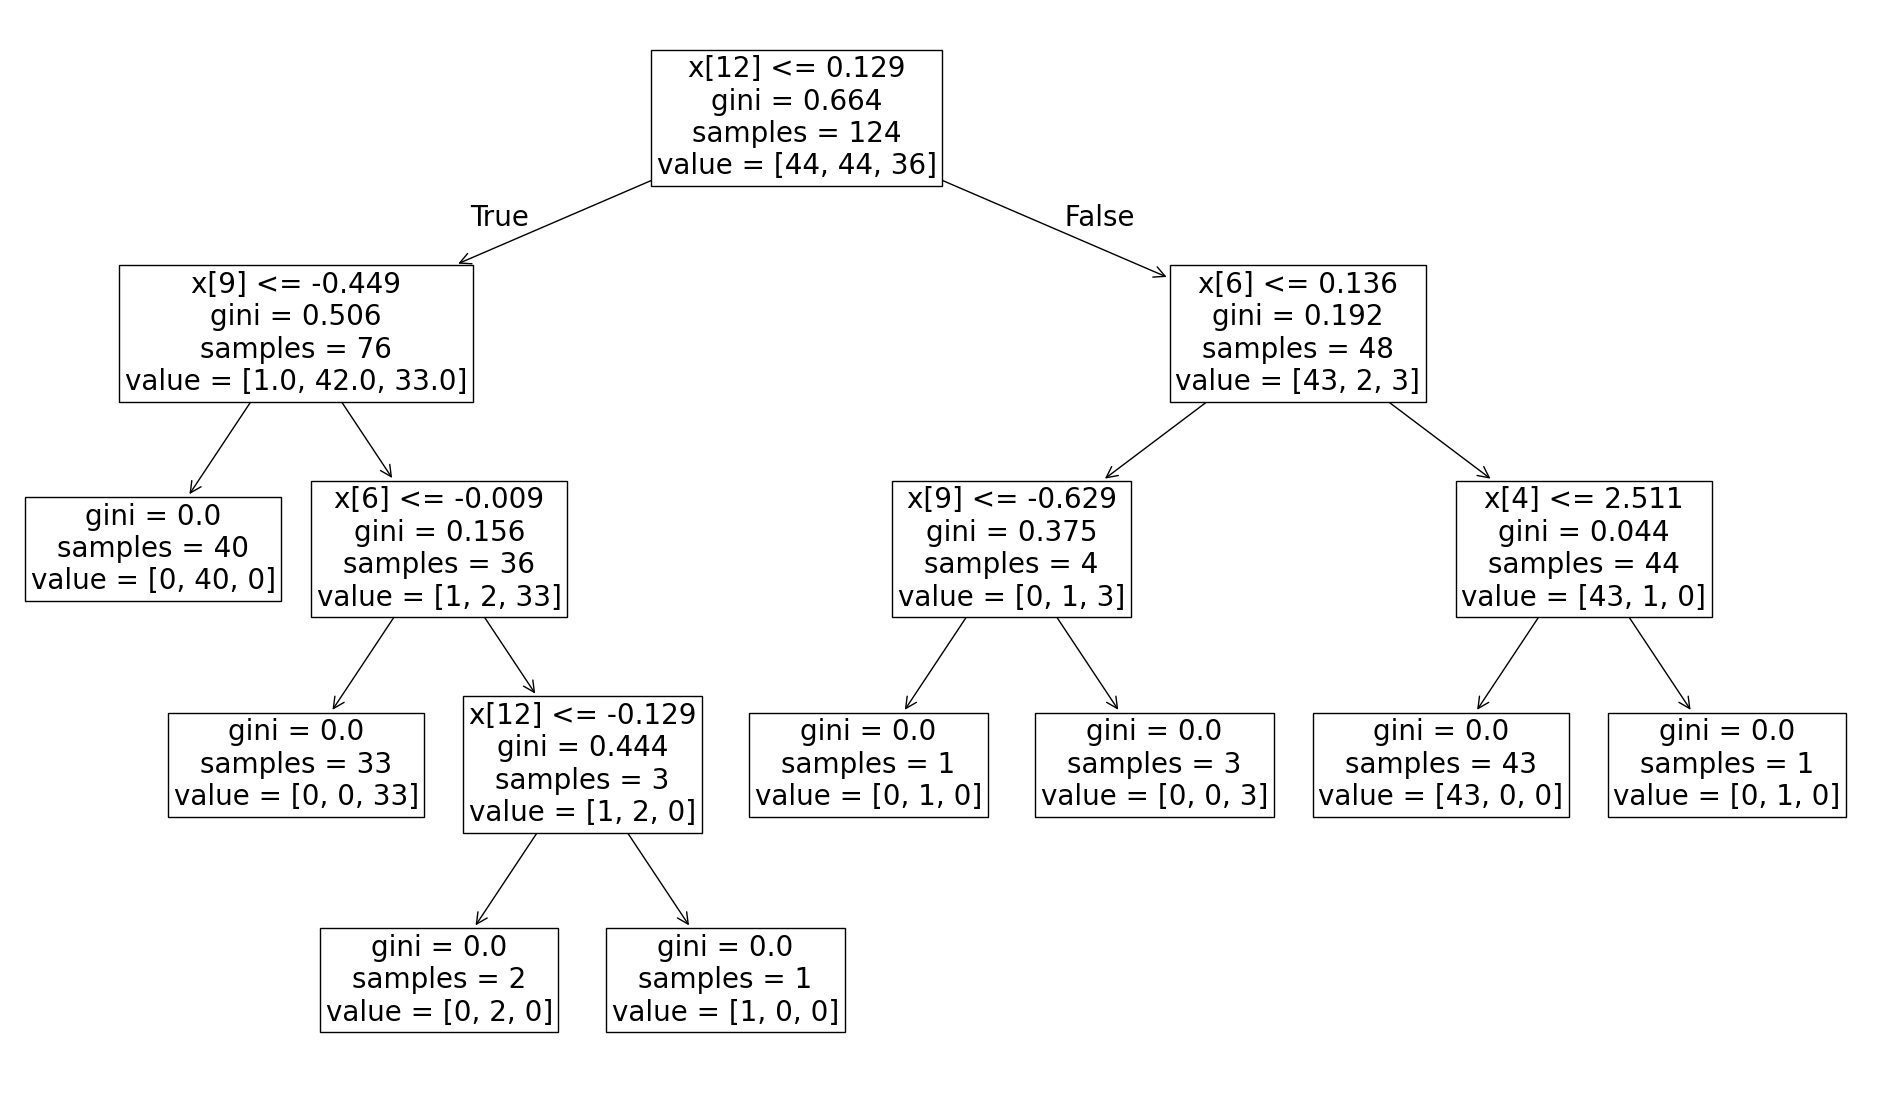

In [23]:
plt.figure(figsize=(24, 14))
tree.plot_tree(DT, fontsize=20)
plt.savefig('decision_tree_high_res.png', dpi=300, bbox_inches='tight')
